# **Name: Chirag Chaudhari**
# **Roll no: 24102A2003**
# **Branch: CMPN-A**

# **Lab 4: Advanced Missing Data Handling**

In [1]:
install.packages(c("dplyr", "naniar", "skimr"))

library(dplyr)
library(naniar)
library(skimr)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gridExtra’, ‘plyr’, ‘norm’, ‘visdat’, ‘viridis’, ‘UpSetR’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘skimr’


The following object is masked from ‘package:naniar’:

    n_complete




In [2]:
# Load Adult dataset

url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

adult_data <- read.csv(
  url,
  header = FALSE,
  na.strings = "?",
  strip.white = TRUE
)

colnames(adult_data) <- c(
  "age", "workclass", "fnlwgt", "education",
  "education_num", "marital_status", "occupation",
  "relationship", "race", "sex", "capital_gain",
  "capital_loss", "hours_per_week",
  "native_country", "income"
)

adult_dirty <- adult_data

head(adult_dirty)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
,<int>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
5,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
6,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


### **Introduce missing/invalid data**

In [3]:
# NA
adult_dirty$age[1:5] <- NA
adult_dirty$hours_per_week[6:8] <- NA

# Blank strings
adult_dirty$workclass[9:11] <- ""
adult_dirty$occupation[12:14] <- ""

# NaN
adult_dirty$capital_gain[15:17] <- NaN

# Impossible age
adult_dirty$age[18:20] <- 999

# Display affected records
adult_dirty[1:20, c(
  "age", "workclass", "occupation",
  "capital_gain", "hours_per_week"
)]

### **Detect different types of missing data**

In [4]:
cat("NA values:", sum(is.na(adult_dirty)), "\n")

cat("NaN values:",
    sum(is.nan(adult_dirty$capital_gain)), "\n")

cat("Blank workclass:",
    sum(adult_dirty$workclass == "", na.rm = TRUE), "\n")

cat("Blank occupation:",
    sum(adult_dirty$occupation == "", na.rm = TRUE), "\n")

cat("Age = 999:",
    sum(adult_dirty$age == 999, na.rm = TRUE), "\n")

# NULL demonstration
x <- NULL
cat("Is x NULL?", is.null(x), "\n")

# Variable-wise missing summary
miss_var_summary(adult_dirty)

NA values: 4262 
NaN values: 0 
Blank workclass: 0 
Blank occupation: 0 
Age = 999: 0 
Is x NULL? TRUE 


variable,n_miss,pct_miss
<chr>,<int>,<num>
occupation,1843,5.66
workclass,1836,5.64
native_country,583,1.79
age,0,0
fnlwgt,0,0
education,0,0
education_num,0,0
marital_status,0,0
relationship,0,0


### **Detect different types of missing data**

In [5]:
cat("NA values:", sum(is.na(adult_dirty)), "\n")

cat("NaN values:",
    sum(is.nan(adult_dirty$capital_gain)), "\n")

cat("Blank workclass:",
    sum(adult_dirty$workclass == "", na.rm = TRUE), "\n")

cat("Blank occupation:",
    sum(adult_dirty$occupation == "", na.rm = TRUE), "\n")

cat("Age = 999:",
    sum(adult_dirty$age == 999, na.rm = TRUE), "\n")

# NULL demonstration
x <- NULL
cat("Is x NULL?", is.null(x), "\n")

# Variable-wise missing summary
miss_var_summary(adult_dirty)

NA values: 4262 
NaN values: 0 
Blank workclass: 0 
Blank occupation: 0 
Age = 999: 0 
Is x NULL? TRUE 


variable,n_miss,pct_miss
<chr>,<int>,<num>
occupation,1843,5.66
workclass,1836,5.64
native_country,583,1.79
age,0,0
fnlwgt,0,0
education,0,0
education_num,0,0
marital_status,0,0
relationship,0,0


### **Before-cleaning missingness**

Missing values: 4262 
Missing percentage: 0.87 %


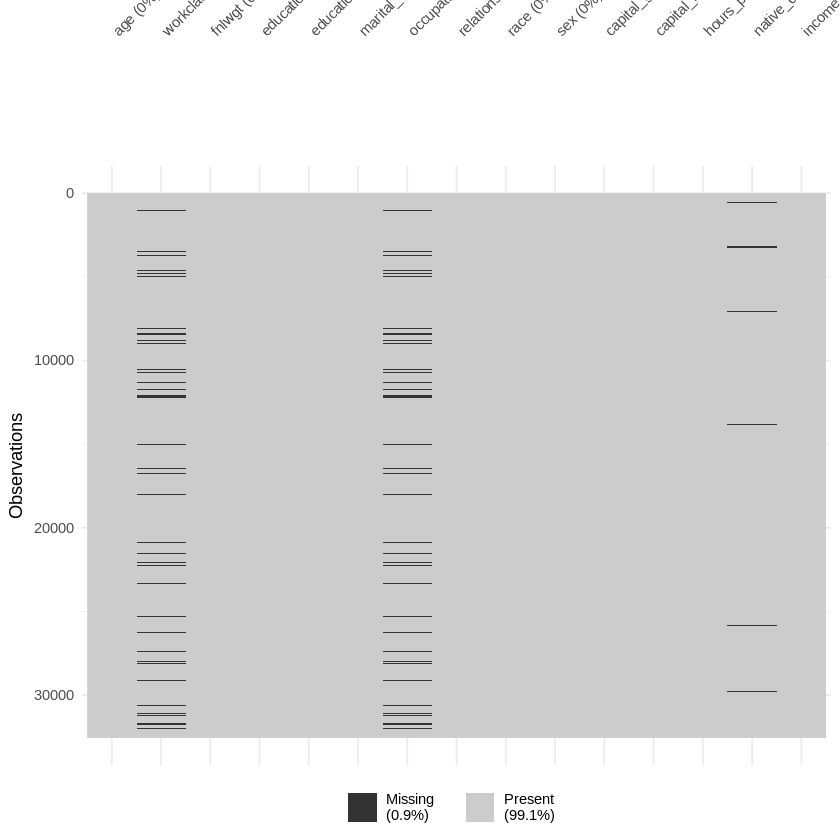

In [6]:
missing_before <- sum(is.na(adult_dirty))
total_values <- nrow(adult_dirty) * ncol(adult_dirty)

percentage_before <- (
  missing_before / total_values
) * 100

cat("Missing values:", missing_before, "\n")
cat("Missing percentage:",
    round(percentage_before, 2), "%\n")

# Visualization
vis_miss(adult_dirty)

### **Create median imputation function**

In [7]:
median_impute <- function(x) {

  median_value <- median(x, na.rm = TRUE)

  x[is.na(x)] <- median_value

  return(x)
}

### **Clean the dataset**

In [12]:
adult_clean <- adult_dirty

# Convert impossible age to NA
adult_clean$age[
  adult_clean$age == 999
] <- NA

# Replace blank categorical values with "Unknown"
adult_clean$workclass[
  adult_clean$workclass == "" | is.na(adult_clean$workclass)
] <- "Unknown"

adult_clean$occupation[
  adult_clean$occupation == "" | is.na(adult_clean$occupation)
] <- "Unknown"

adult_clean$native_country[
  adult_clean$native_country == "" | is.na(adult_clean$native_country)
] <- "Unknown"

# Convert NaN to NA
adult_clean$capital_gain[
  is.nan(adult_clean$capital_gain)
] <- NA

# Median imputation for numeric variables
adult_clean$age <- median_impute(adult_clean$age)

adult_clean$hours_per_week <- median_impute(
  adult_clean$hours_per_week
)

adult_clean$capital_gain <- median_impute(
  adult_clean$capital_gain
)

### **Before vs After comparison**

In [13]:
missing_after <- sum(is.na(adult_clean))

percentage_after <- (
  missing_after / total_values
) * 100

cat("===== BEFORE CLEANING =====\n")
cat("Missing:", missing_before, "\n")
cat("Percentage:",
    round(percentage_before, 2), "%\n\n")

cat("===== AFTER CLEANING =====\n")
cat("Missing:", missing_after, "\n")
cat("Percentage:",
    round(percentage_after, 2), "%\n")

cat("\n===== VARIABLE SUMMARY =====\n")
miss_var_summary(adult_clean)

===== BEFORE CLEANING =====
Missing: 4262 
Percentage: 0.87 %

===== AFTER CLEANING =====
Missing: 0 
Percentage: 0 %

===== VARIABLE SUMMARY =====


variable,n_miss,pct_miss
<chr>,<int>,<num>
age,0,0
workclass,0,0
fnlwgt,0,0
education,0,0
education_num,0,0
marital_status,0,0
occupation,0,0
relationship,0,0
race,0,0


In [14]:
cat("Age = 999:",
    sum(adult_clean$age == 999, na.rm = TRUE), "\n")

cat("Blank workclass:",
    sum(adult_clean$workclass == "", na.rm = TRUE), "\n")

cat("Blank occupation:",
    sum(adult_clean$occupation == "", na.rm = TRUE), "\n")

cat("NaN in capital_gain:",
    sum(is.nan(adult_clean$capital_gain)), "\n")

cat("Incomplete rows:",
    sum(!complete.cases(adult_clean)), "\n")

# Comprehensive validation
skim(adult_clean)

Age = 999: 0 
Blank workclass: 0 
Blank occupation: 0 
NaN in capital_gain: 0 
Incomplete rows: 0 


,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,workclass,0,1,7,16,0,9,0,NA,NA,NA,NA,NA,NA,NA,NA
2,character,education,0,1,3,12,0,16,0,NA,NA,NA,NA,NA,NA,NA,NA
3,character,marital_status,0,1,7,21,0,7,0,NA,NA,NA,NA,NA,NA,NA,NA
4,character,occupation,0,1,5,17,0,15,0,NA,NA,NA,NA,NA,NA,NA,NA
5,character,relationship,0,1,4,14,0,6,0,NA,NA,NA,NA,NA,NA,NA,NA
6,character,race,0,1,5,18,0,5,0,NA,NA,NA,NA,NA,NA,NA,NA
7,character,sex,0,1,4,6,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA
8,character,native_country,0,1,4,26,0,42,0,NA,NA,NA,NA,NA,NA,NA,NA
9,character,income,0,1,4,5,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA


### **visualization + export**

cleaned_adult_data.csv created successfully!

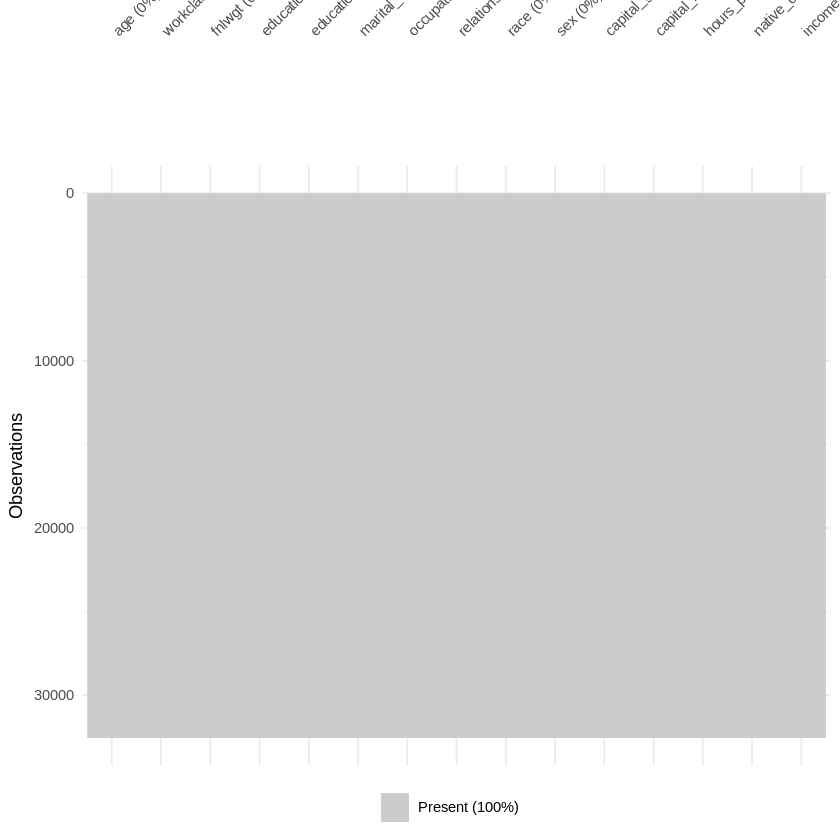

In [15]:
# Visualize remaining missingness
vis_miss(adult_clean)

# Export cleaned dataset
write.csv(
  adult_clean,
  "cleaned_adult_data.csv",
  row.names = FALSE
)

cat("cleaned_adult_data.csv created successfully!")

### **Conclusion:**

The Adult dataset was cleaned by identifying NA, NaN, blank strings,
and impossible age values. Invalid age values were converted to NA,
blank categorical values were replaced with 'Unknown', and missing
numeric values were imputed using the median through a custom function.
Missingness was compared before and after cleaning using naniar.
The cleaned dataset was validated using complete.cases() and
skimr::skim(). The final cleaned dataset was exported as
cleaned_adult_data.csv.